<a href="https://colab.research.google.com/github/SilviaMaharjan/AI-ML_Workshops/blob/main/SilviaMaharjan_2408228_Worksheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Worksheet 4**

# Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification.

**Task 1: Data Preparation**

In [1]:
# import zipfile
# import os

# zip_path = '/content/drive/MyDrive/AI and ML/Copy of devnagari digit.zip'
# extract_to = '/content/drive/MyDrive/AI and ML'

# os.makedirs(extract_to, exist_ok=True)

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_to)

# print("Zip file extracted successfully!")

In [2]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2



Loading training data …
Loading test data …
  [Warning] Could not load /content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset/Test/digit_0/43508.png: cannot identify image file '/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset/Test/digit_0/43508.png'

Training set  : (17000, 28, 28, 1)  |  Labels: (17000, 10)
Test set      : (2999, 28, 28, 1)   |  Labels: (2999, 10)


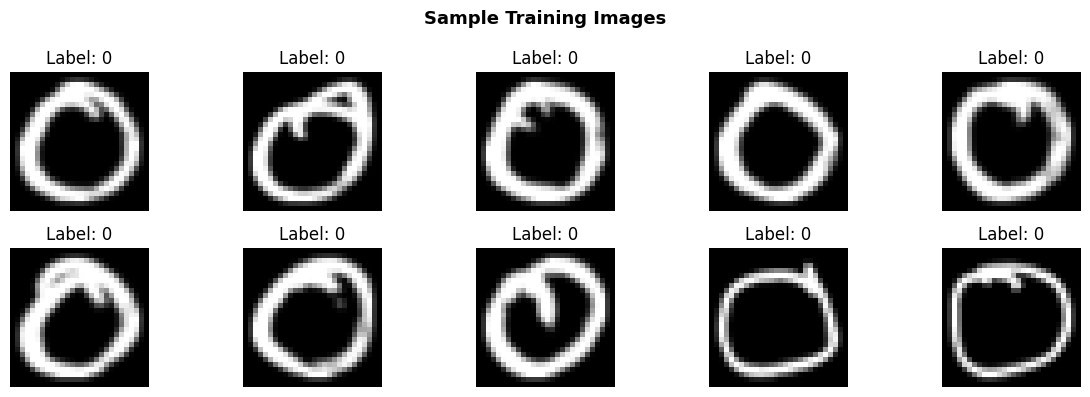

Sample images saved → sample_images.png


In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from PIL import Image

# ── Configuration ──
train_dir  = "/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset/Train"
test_dir   = "/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset/Test"
IMG_HEIGHT = 28
IMG_WIDTH  = 28
NUM_CLASSES = 10


def load_images_from_folder(folder):
    """
    Loads images from a directory structured as:
        folder/
            digit_0/  ← class folders
            digit_1/
            ...
    Returns:
        images : np.ndarray  shape (N, 28, 28)  float32 in [0,1]
        labels : np.ndarray  shape (N,)          int
    """
    images, labels = [], []

    # Sort so class index is consistent (digit_0 → 0, digit_1 → 1, …)
    class_names = sorted(os.listdir(folder))
    class_map   = {name: idx for idx, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        # Skip any non-directory entries (e.g., hidden files)
        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")          # Grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))         # 28 × 28
                img = np.array(img, dtype=np.float32) / 255.0    # Normalize [0, 1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"  [Warning] Could not load {img_path}: {e}")

    return np.array(images), np.array(labels)


# ── Load datasets ──
print("\nLoading training data …")
x_train_raw, y_train_raw = load_images_from_folder(train_dir)

print("Loading test data …")
x_test_raw,  y_test_raw  = load_images_from_folder(test_dir)

# ── Reshape for Keras: (N, 28, 28, 1) ──
x_train = x_train_raw.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
x_test  = x_test_raw.reshape(-1,  IMG_HEIGHT, IMG_WIDTH, 1)

# ── One-hot encode labels ──
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"\nTraining set  : {x_train.shape}  |  Labels: {y_train.shape}")
print(f"Test set      : {x_test.shape}   |  Labels: {y_test.shape}")

# ── Visualise a sample of training images ──
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap="gray")
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=120)
plt.show()
print("Sample images saved → sample_images.png")

**Task 2: Build the FCN Model**

In [4]:
model = Sequential([
    # Input shape matches our image dimensions
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)),

    # Flatten 28×28×1 → 784-dim vector
    Flatten(),

    # Hidden layer 1 – 64 neurons, sigmoid activation
    Dense(64,  activation="sigmoid", name="hidden_1"),

    # Hidden layer 2 – 128 neurons, sigmoid activation
    Dense(128, activation="sigmoid", name="hidden_2"),

    # Hidden layer 3 – 256 neurons, sigmoid activation
    Dense(256, activation="sigmoid", name="hidden_3"),

    # Output layer – 10 neurons (one per Devnagari digit class)
    Dense(NUM_CLASSES, activation="softmax", name="output"),
], name="Devnagari_FCN")

print("\nModel Architecture:")
model.summary()


Model Architecture:


Model: "Devnagari_FCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

**Task 3: Compile the Model**

In [5]:
model.compile(
    optimizer="adam",                        # Adam – adaptive, works well generally
    loss="categorical_crossentropy",         # One-hot encoded labels → categorical CE
    metrics=["accuracy"]
)

print("Model compiled successfully.")
print("  Optimizer : Adam")
print("  Loss      : categorical_crossentropy")
print("  Metric    : accuracy")

Model compiled successfully.
  Optimizer : Adam
  Loss      : categorical_crossentropy
  Metric    : accuracy


**Task 4: Train the Model**


Training for up to 340 epochs  |  batch size = 128
(EarlyStopping will halt training if val_loss stalls for 5 epochs)

Epoch 1/340
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2839 - loss: 2.0339
Epoch 1: val_loss improved from None to 6.92809, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4649 - loss: 1.6635 - val_accuracy: 0.0000e+00 - val_loss: 6.9281
Epoch 2/340
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7917 - loss: 0.7157
Epoch 2: val_loss did not improve from 6.92809
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8274 - loss: 0.5779 - val_accuracy: 0.0000e+00 - val_loss: 7.9170
Epoch 3/340
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9096 - loss: 0.3341
Epoch 3: val_loss did not improve from 6.92809
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9204 - loss: 0.2923 - val_accuracy: 0.0000e+00 - val_loss: 8.7870
Epoch 

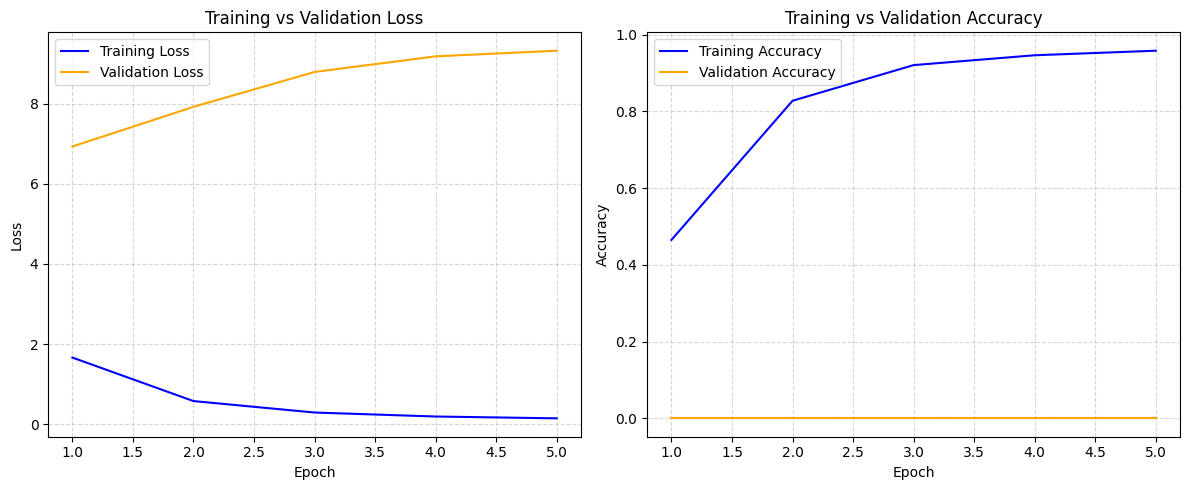

Training curves saved → training_curves.png


In [6]:
BATCH_SIZE = 128
EPOCHS     = 340

callbacks = [
    # Save the best model (lowest val_loss) during training
    ModelCheckpoint(
        filepath="best_devnagari_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    # Stop early if val_loss doesn't improve for 5 consecutive epochs
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
]

print(f"\nTraining for up to {EPOCHS} epochs  |  batch size = {BATCH_SIZE}")
print("(EarlyStopping will halt training if val_loss stalls for 5 epochs)\n")

history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,      # 20% of training data used for validation
    callbacks=callbacks,
    verbose=1
)

# ── Plot training curves ──
train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]
train_acc  = history.history["accuracy"]
val_acc    = history.history["val_accuracy"]
epoch_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epoch_range, train_loss, label="Training Loss",   color="blue")
plt.plot(epoch_range, val_loss,   label="Validation Loss", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epoch_range, train_acc, label="Training Accuracy",   color="blue")
plt.plot(epoch_range, val_acc,   label="Validation Accuracy", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()
print("Training curves saved → training_curves.png")

**Task 5: Evaluate the Model**

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc * 100:.2f}%")

94/94 - 0s - 3ms/step - accuracy: 0.6309 - loss: 2.0921

  Test Loss     : 2.0921
  Test Accuracy : 63.09%


**Task 6: Save and Load the Model**

In [9]:
# ── Save ──
save_path = "/content/drive/MyDrive/AI and ML/devnagari_fcn_model.h5"
model.save(save_path)
print(f"\nModel saved → {save_path}")

# ── Load ──
loaded_model = tf.keras.models.load_model(save_path)
print(f"Model loaded  ← {save_path}")

# ── Re-evaluate loaded model to confirm correctness ──
print("\nRe-evaluating loaded model on test set …")
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\n  Loaded Model Test Loss     : {loaded_loss:.4f}")
print(f"  Loaded Model Test Accuracy : {loaded_acc * 100:.2f}%")


Model saved → /content/drive/MyDrive/AI and ML/devnagari_fcn_model.h5
Model loaded  ← /content/drive/MyDrive/AI and ML/devnagari_fcn_model.h5

Re-evaluating loaded model on test set …
94/94 - 1s - 9ms/step - accuracy: 0.6309 - loss: 2.0921

  Loaded Model Test Loss     : 2.0921
  Loaded Model Test Accuracy : 63.09%


**Task 7: Predictions**


Sample predictions (first 10 test images):
  Index   True Label     Predicted Label   Correct?
  --------------------------------------------------
  0       0              0                 ✓
  1       0              0                 ✓
  2       0              0                 ✓
  3       0              0                 ✓
  4       0              0                 ✓
  5       0              0                 ✓
  6       0              0                 ✓
  7       0              0                 ✓
  8       0              0                 ✓
  9       0              0                 ✓


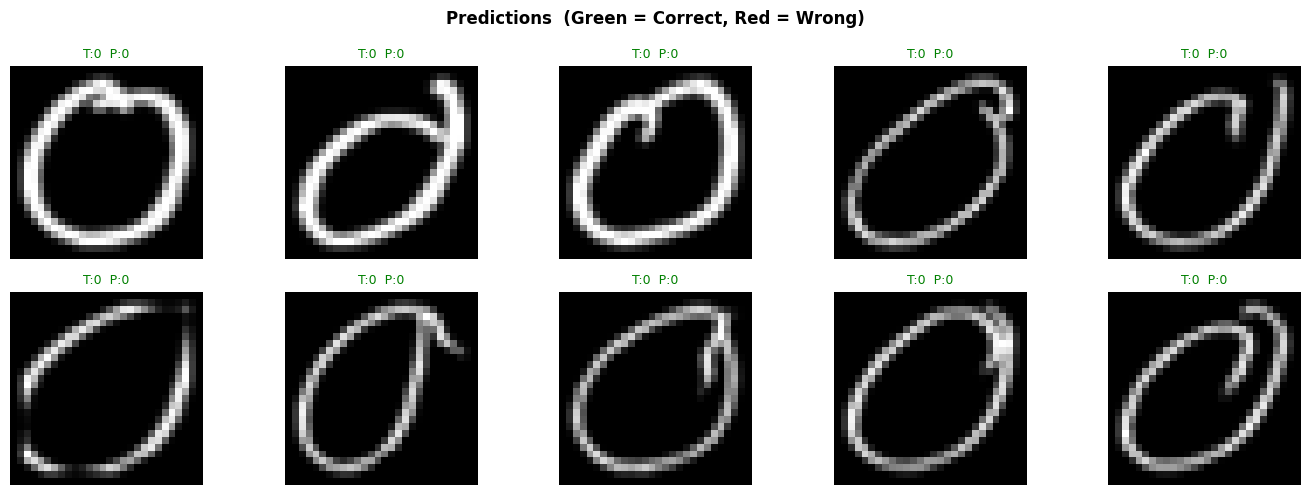


Prediction visualisation saved → predictions.png

FINAL SUMMARY
  Total test samples  : 2999
  Correctly predicted : 1892
  Incorrectly predicted: 1107
  Final Test Accuracy : 63.09%


In [10]:
# ── Get predicted probabilities ──
predictions = loaded_model.predict(x_test, verbose=0)

# ── Convert probabilities → class labels ──
predicted_labels = np.argmax(predictions, axis=1)   # Predicted class
true_labels      = np.argmax(y_test,      axis=1)   # Ground truth class

# ── Print a few individual results ──
print("\nSample predictions (first 10 test images):")
print(f"  {'Index':<8}{'True Label':<15}{'Predicted Label':<18}{'Correct?'}")
print("  " + "-" * 50)
for i in range(10):
    correct = "✓" if predicted_labels[i] == true_labels[i] else "✗"
    print(f"  {i:<8}{true_labels[i]:<15}{predicted_labels[i]:<18}{correct}")

# ── Visualise predictions on test images ──
plt.figure(figsize=(14, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap="gray")
    color = "green" if predicted_labels[i] == true_labels[i] else "red"
    plt.title(f"T:{true_labels[i]}  P:{predicted_labels[i]}", color=color, fontsize=9)
    plt.axis("off")
plt.suptitle("Predictions  (Green = Correct, Red = Wrong)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("predictions.png", dpi=120)
plt.show()
print("\nPrediction visualisation saved → predictions.png")

# ── Overall summary ──
correct   = np.sum(predicted_labels == true_labels)
incorrect = len(true_labels) - correct
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Total test samples  : {len(true_labels)}")
print(f"  Correctly predicted : {correct}")
print(f"  Incorrectly predicted: {incorrect}")
print(f"  Final Test Accuracy : {test_acc * 100:.2f}%")
print("=" * 60)